# Python `break`, `continue`, and `pass`

These three **loop control (transfer) statements** alter a loop's normal execution flow:

| Statement | What it does |
|---|---|
| `break` | Terminates the loop immediately — control jumps to the first statement AFTER the loop |
| `continue` | Skips the rest of the CURRENT iteration only — control jumps back to the loop's condition check |
| `pass` | Does nothing at all — a placeholder, doesn't affect loop flow in any way |

All three work identically in both `for` and `while` loops. This notebook covers each in depth, including their behavior inside nested loops.

## `break`

`break` exits the ENTIRE loop instantly — no further iterations happen, even if the loop's own condition would otherwise still be true. Useful for stopping the moment you've found what you're looking for, avoiding pointless extra work.

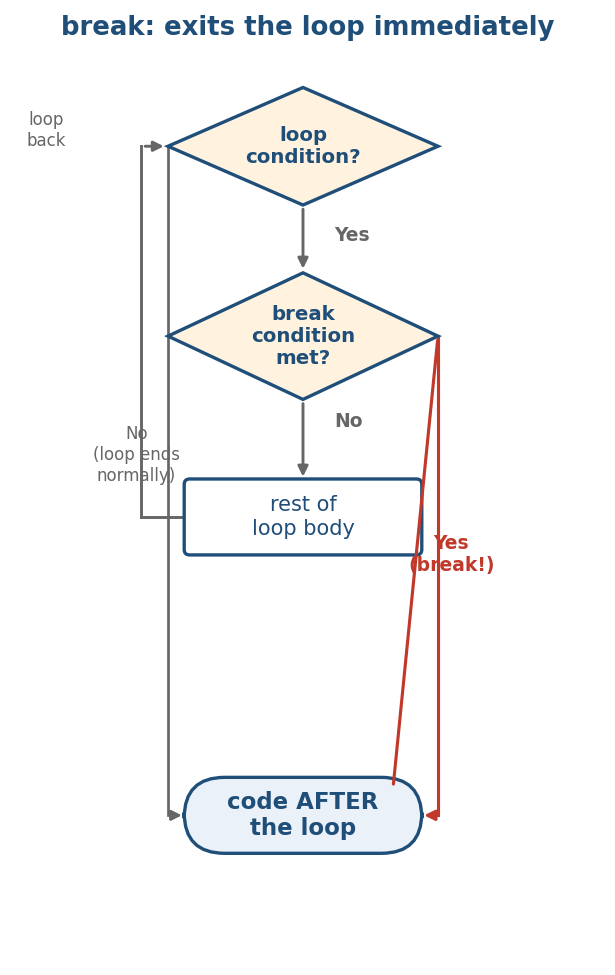

In [ ]:
numbers = [10, 40, 120, 230]

for i in numbers:

    if i > 100:

        break

    print('current number', i)

### How `break` Works, Step by Step

- Pass 1: `i = 10`. `10 > 100` is False -> prints 10.
- Pass 2: `i = 40`. `40 > 100` is False -> prints 40.
- Pass 3: `i = 120`. `120 > 100` is True -> `break` fires, loop ends immediately. 120 and 230 are never even looked at again.

### `break` in a `while` Loop

In [ ]:
name = 'Jesaa29 Roy'

size = len(name)

i = 0

while i < size:

    if name[i].isspace():

        break

    print(name[i], end=' ')

    i = i + 1

### Breaking a Nested Loop

**Important:** `break` only terminates the INNERMOST loop it's directly inside — it has no effect on any OUTER loop wrapping it. Here, once both `i` and `j` exceed 5, only the inner loop stops for that particular row; the outer loop keeps going to the next row.

In [ ]:
for i in range(1, 11):

    print('Multiplication table of', i)

    for j in range(1, 11):

        if i > 5 and j > 5:

            break

        print(i * j, end=' ')

    print('')

### 'Breaking the Outer Loop' — What's Actually Happening

You CANNOT make a `break` inside an inner loop directly terminate an outer loop — a single `break` only ever affects its own immediately-enclosing loop. What actually achieves the effect of 'stopping the outer loop early' is placing the `break` (and its check) directly INSIDE the outer loop's own body, checked BEFORE the inner loop even starts:

In [ ]:
for i in range(1, 11):

    if i > 5:

        break   # this break belongs to the OUTER loop directly - it's not inside the inner loop at all

    print('Multiplication table of', i)

    for j in range(1, 11):

        print(i * j, end=' ')

    print('')

If you genuinely need an inner-loop condition to stop an OUTER loop (not just skip the rest of one outer pass), the common patterns are: a boolean 'stop' flag checked at the top of the outer loop, wrapping the loops in a function and using `return`, or (rarely) raising and catching a custom exception. There's no dedicated 'break outer loop' keyword in Python — unlike some other languages that support labeled breaks.

## `continue`

`continue` skips just the REMAINING code in the current iteration and jumps straight back to the loop's condition check for the NEXT iteration — the loop itself keeps running, unlike `break`.

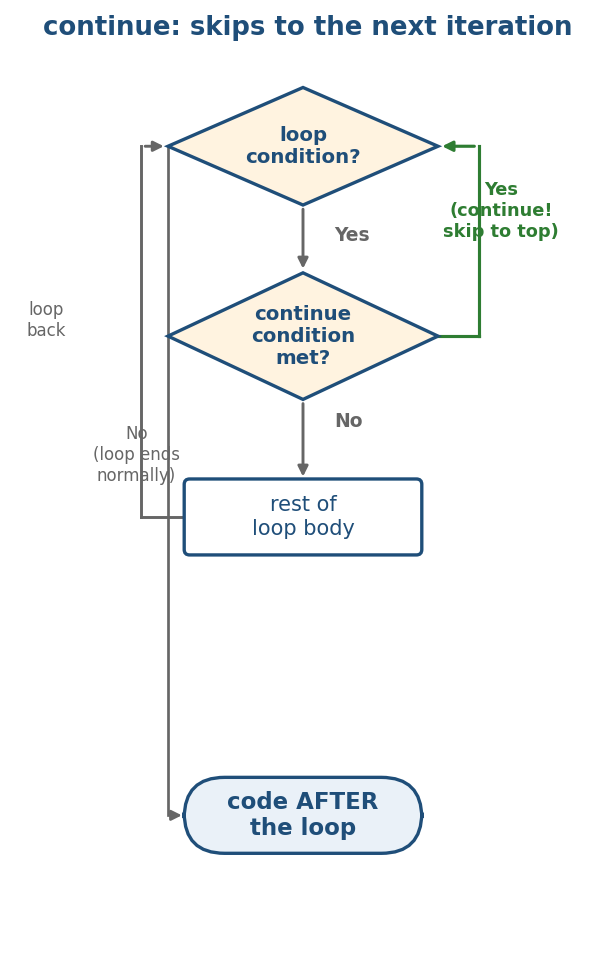

In [ ]:
numbers = [2, 3, 11, 7]

for i in numbers:

    print('Current Number is', i)

    if i > 10:

        continue

    square = i * i

    print('Square of a current number is', square)

### How `continue` Works, Step by Step

- `i = 2`: prints 'Current Number is 2'. `2 > 10` False -> computes and prints the square, 4.
- `i = 3`: prints 'Current Number is 3'. `3 > 10` False -> computes and prints the square, 9.
- `i = 11`: prints 'Current Number is 11'. `11 > 10` True -> `continue` fires, skipping the square calculation entirely for 11.
- `i = 7`: prints 'Current Number is 7'. `7 > 10` False -> computes and prints the square, 49.

### `continue` in a `while` Loop

In [ ]:
name = 'Je sa a'

size = len(name)

i = -1

while i < size - 1:

    i = i + 1

    if name[i].isspace():

        continue

    print(name[i], end=' ')

### `continue` in a Nested Loop

Just like `break`, `continue` only affects the INNERMOST loop it's directly inside.

In [ ]:
for i in range(1, 11):

    print('Multiplication table of', i)

    for j in range(1, 11):

        if j == 5:

            continue

        print(i * j, end=' ')

    print('')

### `continue` in the Outer Loop

Placed directly in the outer loop's own body, `continue` skips the rest of THAT outer pass — which means the inner loop for that pass never runs at all, since the inner loop is itself part of the outer loop's body that got skipped.

In [ ]:
for i in range(1, 11):

    if i % 2 == 0:

        continue   # skip the REST of this outer iteration - the inner loop below never runs for even i

    print('Multiplication table of', i)

    for j in range(1, 11):

        print(i * j, end=' ')

    print('')

## `pass`

`pass` is a genuine no-op — literally nothing happens. It exists purely to satisfy Python's syntax, which requires SOME statement wherever an indented block is expected, even if you have nothing to actually put there yet.

In [ ]:
months = ['January', 'June', 'March', 'April']

for mon in months:

    pass

print(months)

Typical uses: stubbing out a function or class body you'll implement later, or an `if`/`except` branch that's intentionally meant to do nothing for now.

In [ ]:
def process_order(order):

    pass  # TODO: implement order processing logic



class FutureFeature:

    pass  # placeholder class, not implemented yet



try:

    result = 10 / 2

except ZeroDivisionError:

    pass  # deliberately ignore this specific error case

else:

    print("Division succeeded:", result)

## Quick Comparison

| | Stops the loop entirely? | Skips remaining body this pass? | Does anything at all? |
|---|---|---|---|
| `break` | Yes | (loop ends, so moot) | Yes — exits |
| `continue` | No | Yes | Yes — skips ahead |
| `pass` | No | No | No — literally nothing |

## Summary

- `break` exits the CURRENT (innermost) loop entirely and immediately.
- `continue` skips only the rest of the CURRENT iteration, then resumes the loop normally.
- `pass` is a deliberate no-op, used as a syntactic placeholder.
- All three only ever affect the SINGLE loop they're directly, immediately inside — never an outer loop automatically. To end (or skip) an outer loop from logic that's conceptually 'inside' an inner one, you need an explicit flag, a `return` from a wrapping function, or a similar workaround — Python has no labeled-break syntax.

## Practice Exercises

1. Given `values = [4, 9, -3, 15, -7, 22]`, use `break` to print values one at a time until (and not including) the first negative one.
2. Given the same list, use `continue` to print only the positive values, skipping negatives without stopping the loop.
3. Write nested loops (`i` and `j` both `range(1,6)`) that print all `(i, j)` pairs EXCEPT skip printing whenever `i == j` (use `continue`).
4. Write a function `find_pair(matrix, target)` that searches a 2D list (a list of lists) for a target value, using a boolean flag to stop BOTH the inner and outer loop early once found (demonstrating the 'no labeled break' workaround).
5. Write a loop over `range(20)` that uses `pass` for multiples of 3, and prints the number otherwise — confirming `pass` really does nothing observable.

### Exercise 1 solution

In [ ]:
values = [4, 9, -3, 15, -7, 22]

for v in values:

    if v < 0:

        break

    print(v)

### Exercise 2 solution

In [ ]:
values = [4, 9, -3, 15, -7, 22]

for v in values:

    if v < 0:

        continue

    print(v)

### Exercise 3 solution

In [ ]:
for i in range(1, 6):

    for j in range(1, 6):

        if i == j:

            continue

        print(f"({i},{j})", end=" ")

    print()

### Exercise 4 solution

In [ ]:
def find_pair(matrix, target):

    found = False

    for row_idx, row in enumerate(matrix):

        for col_idx, value in enumerate(row):

            if value == target:

                found = True

                print(f"Found {target} at row {row_idx}, col {col_idx}")

                break   # stops only the inner loop

        if found:

            break       # this break is in the OUTER loop, checked right after the inner one

    if not found:

        print(f"{target} not found")



grid = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]

find_pair(grid, 5)

find_pair(grid, 99)

### Exercise 5 solution

In [ ]:
for n in range(20):

    if n % 3 == 0:

        pass

    else:

        print(n, end=" ")